In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [3]:
class SVM:
    """
    Linear SVM trained via subgradient descent on hinge loss
    (Pegasos-style). Minimizes:

        L(w, b) = lambda * ||w||^2 + (1/n) * sum(max(0, 1 - y_i*(w.x_i + b)))
    """

    def __init__(self,
                 learning_rate=0.001,
                 lambda_param=0.01,
                 epochs=1000,
                 decay_lr=True,
                 random_state=None):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.decay_lr = decay_lr
        self.random_state = random_state

        self.w = None
        self.b = None
        self.loss_history = []

    def _hinge_loss(self, X, y):
        margins = 1 - y * (np.dot(X, self.w) + self.b)
        hinge = np.maximum(0, margins).mean()
        reg = self.lambda_param * np.dot(self.w, self.w)
        return reg + hinge

    def fit(self, X, y):

        n_samples, n_features = X.shape

        y = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0.0

        rng = np.random.default_rng(self.random_state)

        for epoch in range(1, self.epochs + 1):

            indices = rng.permutation(n_samples)

            current_lr = (self.lr / (1 + self.lambda_param * epoch)) if self.decay_lr else self.lr

            for idx in indices:
                x_i = X[idx]

                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    self.w -= current_lr * (2 * self.lambda_param * self.w)

                else:
                    self.w -= current_lr * (
                        2 * self.lambda_param * self.w - x_i * y[idx]
                    )
                    self.b -= current_lr * (-y[idx])

            self.loss_history.append(self._hinge_loss(X, y))

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

    def decision_function(self, X):
        """Raw signed distance from the hyperplane (useful for margin plots)."""
        return np.dot(X, self.w) + self.b


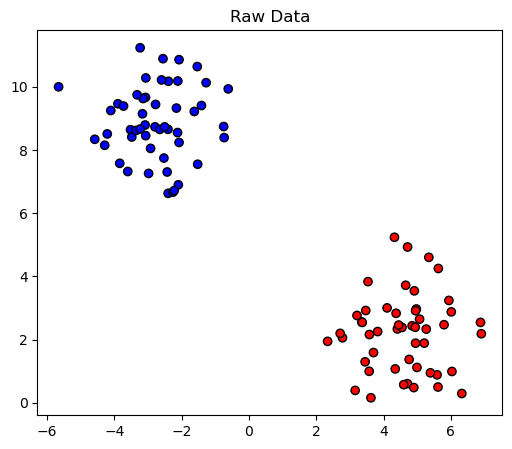

In [4]:
# Data
X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=1.2
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors='k')
plt.title("Raw Data")
plt.show()

In [5]:
model = SVM(lambda_param=0.01, epochs=1000, decay_lr=True, random_state=42)
model.fit(X, y)

pred = model.predict(X)

y_true = np.where(y <= 0, -1, 1)

print("Predictions:", pred)
print("Accuracy:", np.mean(pred == y_true))

Predictions: [-1.  1. -1.  1.  1. -1.  1.  1. -1. -1. -1.  1. -1. -1.  1.  1.  1.  1.
  1. -1.  1.  1.  1.  1.  1. -1.  1. -1.  1.  1. -1. -1. -1. -1. -1.  1.
  1. -1. -1. -1. -1.  1.  1.  1.  1. -1. -1. -1. -1.  1.  1. -1. -1.  1.
 -1.  1. -1.  1.  1. -1. -1.  1. -1.  1.  1.  1.  1. -1.  1.  1. -1.  1.
  1.  1.  1.  1.  1. -1.  1. -1.  1. -1. -1. -1.  1. -1. -1. -1.  1. -1.
  1. -1. -1. -1. -1. -1. -1.  1. -1. -1.]
Accuracy: 1.0


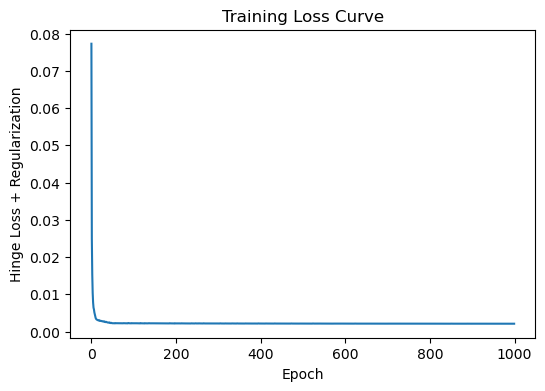

In [6]:
# Loss curve — sanity check that training actually converged
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Hinge Loss + Regularization")
plt.title("Training Loss Curve")
plt.show()

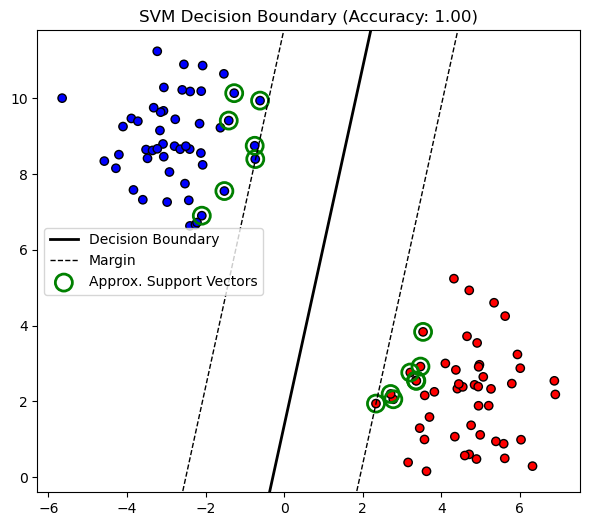

In [7]:
# Decision boundary + margins
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)

# w0*x + w1*y + b = 0  ->  decision boundary
yy_boundary = (-model.w[0] * xx - model.b) / model.w[1]

# w0*x + w1*y + b = 1 and -1 -> the two margins
yy_margin_pos = (1 - model.w[0] * xx - model.b) / model.w[1]
yy_margin_neg = (-1 - model.w[0] * xx - model.b) / model.w[1]

plt.plot(xx, yy_boundary, 'k-', linewidth=2, label='Decision Boundary')
plt.plot(xx, yy_margin_pos, 'k--', linewidth=1, label='Margin')
plt.plot(xx, yy_margin_neg, 'k--', linewidth=1)

distances = np.abs(model.decision_function(X))
support_vector_mask = distances <= np.percentile(distances, 15)
plt.scatter(X[support_vector_mask, 0], X[support_vector_mask, 1],
            s=150, facecolors='none', edgecolors='green', linewidths=2,
            label='Approx. Support Vectors')

plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.title(f"SVM Decision Boundary (Accuracy: {np.mean(pred == y_true):.2f})")
plt.show()

In [8]:
from sklearn.svm import SVC

sklearn_model = SVC(kernel='linear', C=1.0)
sklearn_model.fit(X, y)

print("\n--- Comparison with sklearn SVC(kernel='linear') ---")
print("Scratch  w:", model.w, " b:", model.b)
print("sklearn  w:", sklearn_model.coef_[0], " b:", sklearn_model.intercept_[0])
print("sklearn Accuracy:", sklearn_model.score(X, y))


--- Comparison with sklearn SVC(kernel='linear') ---
Scratch  w: [ 0.45145209 -0.09546615]  b: 0.1301330904957192
sklearn  w: [ 0.28465809 -0.17755842]  b: 0.6995645425778926
sklearn Accuracy: 1.0
